In [78]:
import importlib
import numpy as np
import sys
sys.path.insert(0, '..')

import mcmc_polymer.lattice_rosenbluth as _lr_mod
import mcmc_polymer.pivot_alg as _pv_mod
importlib.reload(_lr_mod)
importlib.reload(_pv_mod)
from mcmc_polymer.lattice_rosenbluth import LatticeRosenbluthMCMC
from mcmc_polymer.pivot_alg import PivotAlgorithm

import potentials.morse_discrete as _morse_mod
importlib.reload(_morse_mod)
from potentials.morse_discrete import DiscreteMorsePotential
from potentials.harmonic_wall_discrete import DiscreteHarmonicWallPotential

In [79]:
CHAIN_LENGTHS  = [110]
N_SAMPLES      = 1000
N_PIVOT_STEPS  = 100
start_position = np.array([0.0, 0.0, 0.0])   # start inside both walls

# ── potentials ────────────────────────────────────────────────────────────────
# Morse wall along z at z=0  (r_e=0 → minimum energy exactly at the wall surface)
morse_wall     = DiscreteMorsePotential(D_e=1.0, a=1.0, r_e=0.0, axis=2, cutoff=2)
# Harmonic wall along y at y=-1
harmonic_wall  = DiscreteHarmonicWallPotential(k=10.0, wall_position=-1, axis=1)

# ── hard walls matching the two potentials ────────────────────────────────────
# (axis, coord, side): side='<' excludes coord and everything below
# this is done so that the starting position is not within the excluded region of either wall,
# which would lead to zero weight for all samples
WALLS = [
    (2, -1, '<'),    # z <= -1 excluded  →  matches morse_wall at z=0
    (1, -1, '<'),   # y <= -1 excluded →  matches harmonic_wall at y=-1
]

pivot_results = {}

for N in CHAIN_LENGTHS:

    ros_sampler   = LatticeRosenbluthMCMC(n_monomers=N + 1, walls=WALLS)
    pivot_sampler = PivotAlgorithm(n_steps=N_PIVOT_STEPS,
                                   potentials=[morse_wall, harmonic_wall])

    com_samples      = []
    acceptance_rates = []

    for _ in range(N_SAMPLES):
        chain, weight = ros_sampler.grow_chain(start=start_position)
        while weight == 0:
            chain, weight = ros_sampler.grow_chain(start=start_position)

        chain, _ = pivot_sampler.run(chain)
        acceptance_rates.append(pivot_sampler.acceptance_rate)
        com_samples.append(chain.mean(axis=0))

    com_samples      = np.array(com_samples)
    acceptance_rates = np.array(acceptance_rates)

    pivot_results[N] = {'com': com_samples, 'acceptance_rates': acceptance_rates}

    print(f"N={N}")
    print(f"  avg pivot acceptance rate : {acceptance_rates.mean():.3f} ± {acceptance_rates.std():.3f}")
    print(f"  x_CoM : {com_samples[:,0].mean():+.3f} ± {com_samples[:,0].std():.3f}")
    print(f"  y_CoM : {com_samples[:,1].mean():+.3f} ± {com_samples[:,1].std():.3f}  (harmonic wall y=-1)")
    print(f"  z_CoM : {com_samples[:,2].mean():+.3f} ± {com_samples[:,2].std():.3f}  (Morse wall z=0)")

N=110
  avg pivot acceptance rate : 0.160 ± 0.071
  x_CoM : +0.346 ± 5.685
  y_CoM : +6.282 ± 2.838  (harmonic wall y=-1)
  z_CoM : +2.519 ± 1.420  (Morse wall z=0)


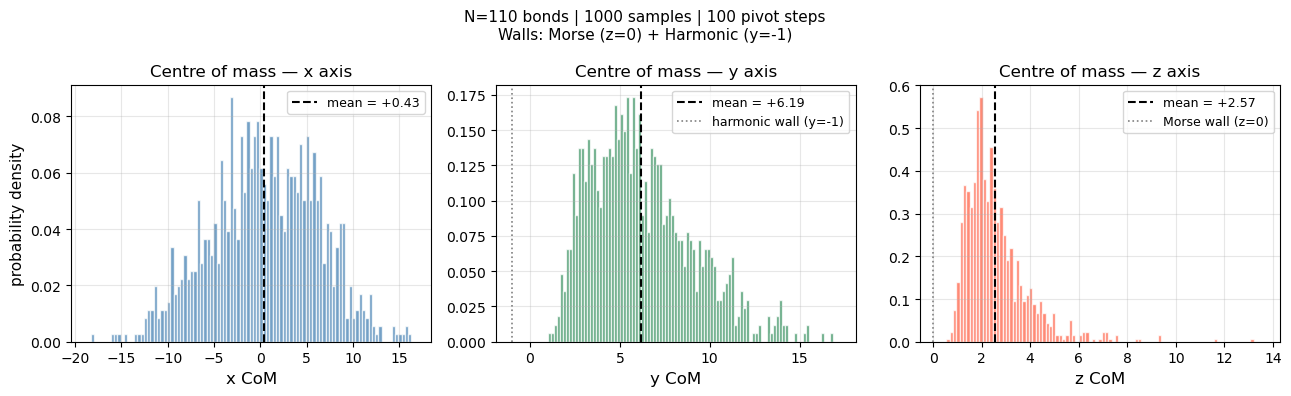

In [75]:
import matplotlib.pyplot as plt

axis_labels = ['x', 'y', 'z']
colors      = ['steelblue', 'seagreen', 'tomato']

# wall positions to annotate on the plots (axis_name → (coord, label))
wall_markers = {
    'y': (-1, 'harmonic wall (y=-1)'),
    'z': ( 0, 'Morse wall (z=0)'),
}

for N in CHAIN_LENGTHS:
    com = pivot_results[N]['com']   # (N_SAMPLES, 3)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    for col, (ax, axis_name, color) in enumerate(zip(axes, axis_labels, colors)):
        data = com[:, col]
        bins = np.linspace(data.min() - 0.5, data.max() + 0.5, 100)

        ax.hist(data, bins=bins, density=True, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(data.mean(), color='k', linestyle='--', linewidth=1.5,
                   label=f'mean = {data.mean():+.2f}')

        if axis_name in wall_markers:
            coord, wall_label = wall_markers[axis_name]
            ax.axvline(coord, color='grey', linestyle=':', linewidth=1.2, label=wall_label)

        ax.set_xlabel(f'{axis_name} CoM', fontsize=12)
        ax.set_ylabel('probability density' if col == 0 else '', fontsize=11)
        ax.set_title(f'Centre of mass — {axis_name} axis', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f'N={N} bonds | {N_SAMPLES} samples | {N_PIVOT_STEPS} pivot steps\n'
        f'Walls: Morse (z=0) + Harmonic (y=-1)',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(f'../data/com_distribution_N{N}.png', dpi=150, bbox_inches='tight')
    plt.show()